In [1]:
words = open('names.txt', 'r').read().splitlines()

In [5]:
import torch

chars = sorted(list(set(''.join(words))))
stoi = {s:i for i,s in enumerate(chars)} #integer index and actual element of the list-enumerate-->mapping char to integer
stoi['<S>'] = 26
stoi['<E>'] = 27
N=torch.zeros((28,28), dtype=torch.int32)  #26 char + 2 special chars

In [10]:
b = {}
for w in words:
    chs = ['<S>']+list(w) +['<E>']
    for ch1, ch2 in zip(chs, chs[1:]):  #chs-><S> chs[1:]-><e>
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1,ix2] +=1
        bigram = (ch1,ch2)
        b[bigram] = b.get(bigram, 0) +1 #.get returns count if none return 0 and add 1 regardless 
        # print(ch1,ch2)

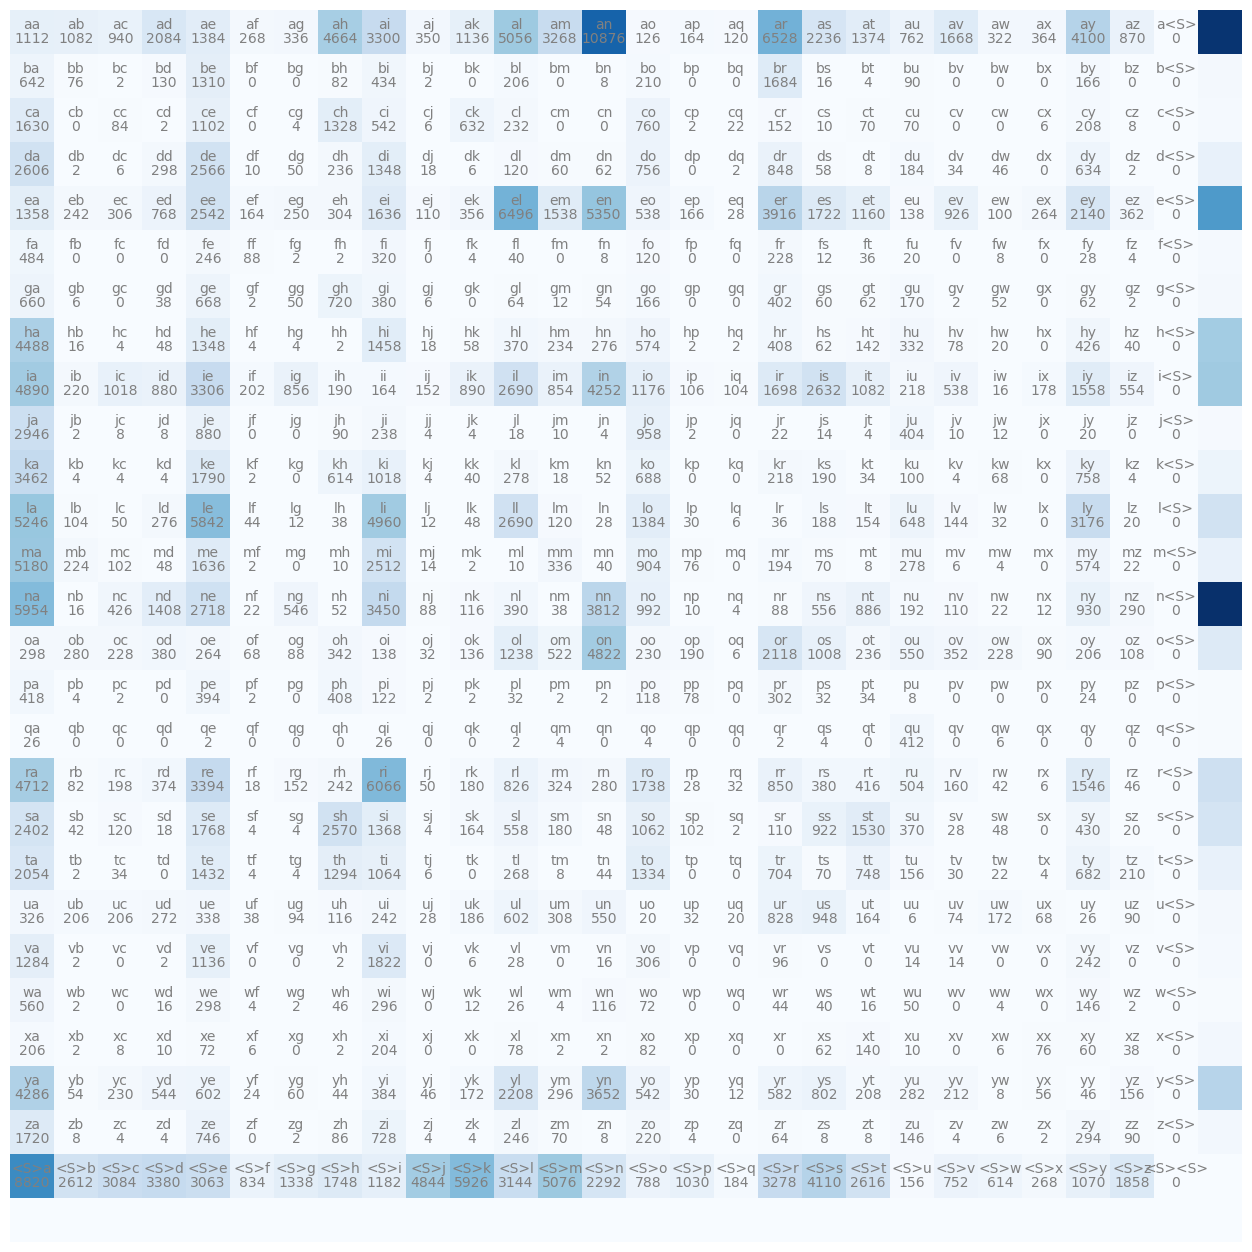

In [11]:
import matplotlib.pyplot as plt
%matplotlib inline
itos = {i:s for s,i in stoi.items()}
plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color='gray')
plt.axis('off');


In [17]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [18]:
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [19]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [56]:

block_size = 5 

def build_dataset(words):  
  X, Y = [], []
  for w in words:


    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix]

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182437, 5]) torch.Size([182437])
torch.Size([22781, 5]) torch.Size([22781])
torch.Size([22928, 5]) torch.Size([22928])


In [59]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 10), generator=g) #27 possible chars, each represented by 10-dimensional embedding
W1 = torch.randn((50, 200), generator=g) #3 context size * 10 d embedding -> 30, 200 hidden features
b1 = torch.randn(200, generator=g) #w1 already uses tanh so it automatically squashes everything in range, w2 is the last operation connected to softmax therefore larger logits directly affect softmax output and be highly confident for random classes prediction, so doing this prevents that
W2 = torch.randn((200, 27), generator=g) * 0.01 # to reduce large logits and hence get initialization loss converge to initial 3.29
b2 = torch.randn(27, generator=g) #b2,b1 should be 0 to cause random initialization creates random output preferences and biases for characters
parameters = [C, W1, b1, W2, b2]

In [60]:
#####EXPERIMENTATION
import math
# ix = torch.randint(0, Xtr.shape[0], (32,))
emb = C[Xtr] #remove mini batch bias
# emb = C[Xtr[ix]]
h = torch.tanh(emb.view(-1, 50) @ W1 + b1)
logits = h @ W2 + b2

loss = F.cross_entropy(logits, Ytr)

print("target =", math.log(27))
print("actual =", loss.item())

target = 3.295836866004329
actual = 3.7181577682495117


In [ ]:
###FROM THE PAPER -> adding direct shortcut to embeddings and output. embeddings->hidden->output uptill now. 

In [68]:
### Embeddings -> Output as shortcut (as described in the paper)
n_embed = 10
W_direct = torch.randn(
    (block_size * n_embed, 27),
    generator=g
) * 0.01
parameters = [C, W1, b1, W2, b2, W_direct]
embcat = emb.view(-1, block_size * n_embed)

h = torch.tanh(embcat @ W1 + b1)

logits = h @ W2 + embcat @ W_direct + b2

In [66]:
#initialization loss
loss = F.cross_entropy(logits, Ytr)
print("actual =", loss.item())

actual = 3.727707624435425


In [ ]:
### TRYING OUT FRESH TRAINING ON THIS 

In [78]:
n_embed = 10
W_direct = torch.randn(
    (block_size * n_embed, 27),
    generator=g
) * 0.01
parameters = [C, W1, b1, W2, b2, W_direct]

In [79]:
sum(p.nelement() for p in parameters)

17247

In [80]:
for p in parameters:
  p.requires_grad = True

In [81]:
#learning rate, random 1000 nums btw -3,0 and raised to power 10
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

lri = [] #lr ind
lossi = [] # loss index
stepi = [] # step iterator

In [82]:
#training with direct connection


for i in range(200000):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (32,))
  emb = C[Xtr[ix]]
  # forward pass
  embcat = emb.view(-1, block_size * n_embed)
  h = torch.tanh(embcat @ W1 + b1)
  logits = h @ W2 + embcat @ W_direct + b2
  loss = F.cross_entropy(logits, Ytr[ix])
  #print(loss.item())
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  #lr = lrs[i]
  lr = 0.1 if i < 100000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  #lri.append(lre[i])
  stepi.append(i)
  lossi.append(loss.log10().item())

#print(loss.item())

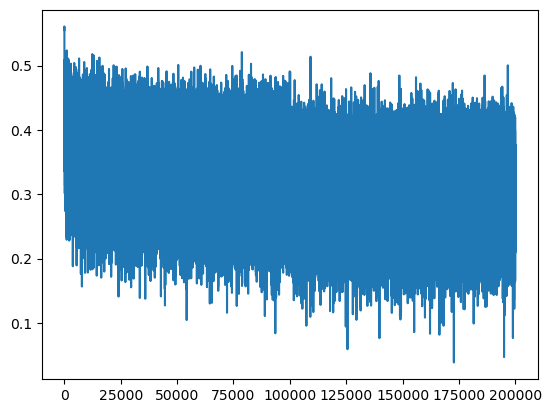

In [83]:
plt.plot(stepi, lossi)

In [84]:
# training loss ---- updated to context 5 size/shape will differ from now
emb = C[Xtr] # (32, 3, 2)
embcat = emb.view(-1, block_size * n_embed)
h = torch.tanh(embcat @ W1 + b1) # (32, 100)
logits = h @ W2 + embcat @ W_direct + b2
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.0227, grad_fn=<NllLossBackward0>)

In [85]:
# validation loss
emb = C[Xdev] # (32, 3, 2)
embcat = emb.view(-1, block_size * n_embed)
h = torch.tanh(embcat @ W1 + b1) # (32, 100)
logits = h @ W2 + embcat @ W_direct + b2
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.1163, grad_fn=<NllLossBackward0>)

In [ ]:
### Simpler training without shortcut

In [35]:
sum(p.nelement() for p in parameters) #total number of parameters

15897

In [36]:
for p in parameters:
  p.requires_grad = True

In [37]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [38]:
lri = []
lossi = []
stepi = []

In [47]:
for i in range(200000):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (32,))
  
  # forward pass
  emb = C[Xtr[ix]] # (32, 3, 2)
  h = torch.tanh(emb.view(-1, 50) @ W1 + b1) # (32, 100)
  logits = h @ W2 + b2 # (32, 27)
  loss = F.cross_entropy(logits, Ytr[ix])
  #print(loss.item())
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  #lr = lrs[i]
  lr = 0.1 if i < 100000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  #lri.append(lre[i])
  stepi.append(i)
  lossi.append(loss.log10().item())

#print(loss.item())

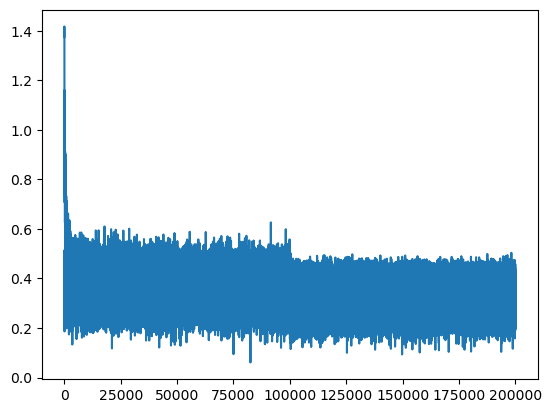

In [48]:
plt.plot(stepi, lossi)

In [49]:
# training loss ---- updated to context 5 size/shape will differ from now
emb = C[Xtr] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 50) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.1079, grad_fn=<NllLossBackward0>)

In [50]:
# validation loss
emb = C[Xdev] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 50) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.1413, grad_fn=<NllLossBackward0>)

In [30]:
# test loss
emb = C[Xte] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Yte)
loss

tensor(2.1644, grad_fn=<NllLossBackward0>)

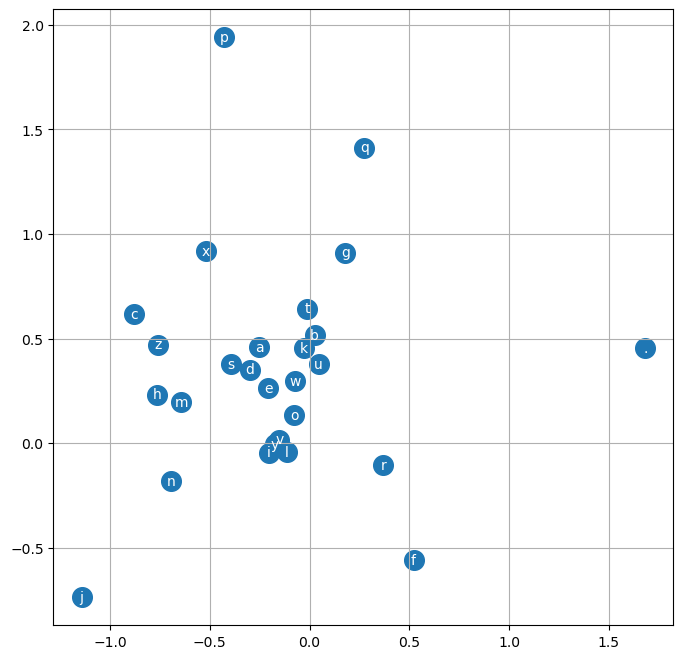

In [31]:
# visualize dimensions 0 and 1 of the embedding matrix C for all characters
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

In [32]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

carmah.
amelle.
khy.
myleremilah.
cassie.
mahnen.
delynn.
pareei.
nellara.
chaiir.
kaleigh.
ham.
pora.
quinn.
suline.
liveni.
watthoniearyxe.
fine.
pilracee.
deci.


In [ ]:
# Have increased context size from 3 to 5 which yielded better result than the initial papers A Neural Probabilistic Language Model

## BATCHNORM

Initializing weights and biases as zero

In [86]:
#dataset
block_size = 3

def build_dataset(words):  
  X, Y = [], []
  
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # slide the context window

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([182441, 3]) torch.Size([182441])
torch.Size([22902, 3]) torch.Size([22902])
torch.Size([22803, 3]) torch.Size([22803])


In [105]:
n_embd = 10
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647)
C  = torch.randn((vocab_size, n_embd),            generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * 0 #* 0.2
#b1 = torch.randn(n_hidden,                        generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0
b2 = torch.randn(vocab_size,                      generator=g) * 0

bnstd_running = torch.ones((1, n_hidden)) * 0



In [106]:
# Initialzing BatchNorm parameters
bngain = torch.ones((1, n_hidden)) * 0
bnbias = torch.zeros((1, n_hidden)) * 0 
bnmean_running = torch.zeros((1, n_hidden)) * 0


In [107]:
parameters = [C, W1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

12097


In [108]:
hpreact.shape

torch.Size([32, 200])

In [94]:
#mean across 0th dim of hpreact
hpreact.mean(0, keepdim=True).shape #mean over all the elements in the batch

torch.Size([1, 200])

In [ ]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass -> entire hidden network becomes x->0,0,0,0 until final layer
  emb = C[Xb] # embed the characters into vectors
  embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
  # Linear layer
  hpreact = embcat @ W1 #+ b1 # hidden layer pre-activation ------> becomes zero
 
    
    # BatchNorm layer

    
  bnmeani = hpreact.mean(0, keepdim=True)
  bnstdi = hpreact.std(0, keepdim=True)
  hpreact = bngain * (hpreact - bnmeani) / (bnstdi + 1e-5) + bnbias
  with torch.no_grad():
    bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani  # --> zero
    bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi   # zero
  # -------------------------------------------------------------
  # Non-linearity
  h = torch.tanh(hpreact) # hidden layer ->tanh(0)=0  every neuron outputs 0
  logits = h @ W2 + b2 # output layer
  loss = F.cross_entropy(logits, Yb)  # ~ log(vocab_size) loss is non zero; so grad exists for logits; loss function #p - y--> p is 1/27 and logits are 0 for each class(uniform distribution)
  #hence, last layer, gradients wrt logits ≠ 0, output layer will not have 0 weights cause its directly connected with loss
 #network becomes -> embedding -> 1hidden neuron -> output layer instead 100 different neurons
  #only b2 learns cause logits = b2
    
    
    #layers[i].weight.grad.std()
    #layers[i].out.std()
    #all hidden activations identical
    # all hidden gradients identical

    #Random initialization is not about making gradients exist. It is about making neurons different.
    
  # backward pass
  for p in parameters:
    p.grad = None
      
  loss.backward()
  if i == 0:
    print("W1 grad std:", W1.grad.std().item())
    print("W2 grad std:", W2.grad.std().item())
    print("b2 grad std:", b2.grad.std().item())
    print("gamma grad std:", bngain.grad.std().item())

    print("hidden std:", h.std().item())
    print("logits std:", logits.std().item())

    print("bn mean max:", bnmeani.abs().max().item())
    print("bn std max:", bnstdi.abs().max().item())  
  # for p in parameters:
  #   print(p.shape, p.grad.abs().mean())



  # update
  lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())
  

In [112]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    # minibatch
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    # forward
    emb = C[Xb]
    embcat = emb.view(emb.shape[0], -1)

    hpreact = embcat @ W1
    h = torch.tanh(hpreact)

    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Yb)

    # backward
    for p in parameters:
        p.grad = None

    loss.backward()

    # inspect only first step
    if i == 0:
        print("\n Without batchnorm")
        print("loss:", loss.item()) #-loss(log(1/27))

        print("hidden std:", h.std().item())
        print("logits std:", logits.std().item())

        print("W1 grad mean:", W1.grad.abs().mean().item())
        print("W1 grad std :", W1.grad.std().item())

        print("W2 grad mean:", W2.grad.abs().mean().item())
        print("W2 grad std :", W2.grad.std().item())

        print("b2 grad mean:", b2.grad.abs().mean().item())
        print("b2 grad std :", b2.grad.std().item())

        break

    # update
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    lossi.append(loss.log10().item())


 Without batchnorm
loss: 3.295837163925171
hidden std: 0.0
logits std: 0.0
W1 grad mean: 0.0
W1 grad std : 0.0
W2 grad mean: 0.0
W2 grad std : 0.0
b2 grad mean: 0.042866941541433334
b2 grad std : 0.05552216246724129


In [111]:
max_steps = 200000
batch_size = 32

for i in range(max_steps):

    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    emb = C[Xb]
    embcat = emb.view(emb.shape[0], -1)

    hpreact = embcat @ W1

    bnmeani = hpreact.mean(0, keepdim=True)
    bnstdi = hpreact.std(0, keepdim=True)

    hpreact = (
        bngain *
        (hpreact - bnmeani) /
        (bnstdi + 1e-5)
        + bnbias
    )

    with torch.no_grad():
        bnmean_running = (
            0.999 * bnmean_running
            + 0.001 * bnmeani
        )

        bnstd_running = (
            0.999 * bnstd_running
            + 0.001 * bnstdi
        )

    h = torch.tanh(hpreact)

    logits = h @ W2 + b2
    #b2 is directly added, no multiplication, no hidden layer, no tanh. Computation graph is b2 --> + --> logits-->loss . Nothing blocks it, grad reaches b2
    #b2 has upstream grad. local deriative 1. While w2 has upstream grad but local derivative h = 0. For w1 upstream grad already becomes 0.
    loss = F.cross_entropy(logits, Yb)

    for p in parameters:
        p.grad = None

    loss.backward()

    if i == 0:
        print("\n With batchnorm")
        print("loss:", loss.item())

        print("bn mean max:",
              bnmeani.abs().max().item())

        print("bn std max:",
              bnstdi.abs().max().item())

        print("hidden std:",
              h.std().item())

        print("logits std:",
              logits.std().item())

        print("W1 grad mean:",
              W1.grad.abs().mean().item())

        print("W2 grad mean:",
              W2.grad.abs().mean().item())

        print("b2 grad mean:",
              b2.grad.abs().mean().item())

        print("gamma grad mean:",
              bngain.grad.abs().mean().item())

        break


 With batchnorm
loss: 3.295837163925171
bn mean max: 0.0
bn std max: 0.0
hidden std: 0.0
logits std: 0.0
W1 grad mean: 0.0
W2 grad mean: 0.0
b2 grad mean: 0.035922497510910034
gamma grad mean: 0.0


Fold BatchNorm into Linear Layer

In [113]:

with torch.no_grad():

    Xtest = Xdev[:128]


    # Original model - BatchNorm
    

    emb = C[Xtest]
    embcat = emb.view(emb.shape[0], -1)

    hpreact = embcat @ W1

    hpreact_bn = (
        bngain
        * (hpreact - bnmean_running)
        / (bnstd_running + 1e-5)
        + bnbias
    )

    h = torch.tanh(hpreact_bn)

    logits_original = h @ W2 + b2


    # Fold BatchNorm into W1


    scale = bngain / (bnstd_running + 1e-5)

    W1_fold = W1 * scale

    b1_fold = bnbias - scale * bnmean_running


    # New model (WITHOUT BatchNorm)


    emb = C[Xtest]
    embcat = emb.view(emb.shape[0], -1)

    hpreact_folded = embcat @ W1_fold + b1_fold

    h_folded = torch.tanh(hpreact_folded)

    logits_folded = h_folded @ W2 + b2


    #verifying

    max_diff = (logits_original - logits_folded).abs().max()

    print("Max Difference :", max_diff.item())

    print(
        "Outputs Match  :",
        torch.allclose(
            logits_original,
            logits_folded,
            atol=1e-5
        )
    )

Max Difference : 0.0
Outputs Match  : True
